# Instacart Midterm Exam — PySpark
# Srbuhi Khachatryan

### Install dependencies

In [1]:
import sys
import subprocess

result = subprocess.run(
    [sys.executable, "-m", "pip", "install", "pyspark", "pandas",
     "numpy", "matplotlib", "seaborn", "--quiet"],
    capture_output=True, text=True
)
print(result.stdout if result.stdout else "Already installed — nothing to do.")
print(result.stderr[:300] if result.returncode != 0 else "")

import pyspark
print(f"PySpark version : {pyspark.__version__}")


Already installed — nothing to do.

PySpark version : 4.1.1


## Imports

In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

# Data & visualisation 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns

# PySpark 
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import StringType
from pyspark.sql.window import Window

print("All imports OK")


All imports OK


## Start Spark Session

In [3]:
from pyspark.sql import SparkSession

# Stop previous broken session
try:
    spark.stop()
except:
    pass

# Create stable Spark session
spark = (
    SparkSession.builder
    .master("local[2]")  
    .appName("InstacartMidterm")

    # Memory
    .config("spark.driver.memory", "2g")
    .config("spark.executor.memory", "2g")

    # Shuffle optimization
    .config("spark.sql.shuffle.partitions", "4")

    # Stability
    .config("spark.ui.showConsoleProgress", "false")
    .config("spark.sql.execution.arrow.pyspark.enabled", "false")
    .config("spark.sql.repl.eagerEval.enabled", "false")

    .getOrCreate()
)

spark.sparkContext.setLogLevel("ERROR")

print(f"Spark {spark.version}")
print(f"Parallelism: {spark.sparkContext.defaultParallelism}")

Spark 4.1.1
Parallelism: 2


## Data Paths


In [4]:
DATA_DIR = r"C:/Users/User/Desktop/Mag1/Big data/Midterm/data" 

PRODUCTS_CSV = os.path.join(DATA_DIR, "products.csv")
ORDERS_CSV   = os.path.join(DATA_DIR, "orders.csv")
OP_PRIOR_CSV = os.path.join(DATA_DIR, "order_products__prior.csv")
DEPTS_CSV    = os.path.join(DATA_DIR, "departments.csv")
AISLES_CSV   = os.path.join(DATA_DIR, "aisles.csv")

all_ok = True
for path in [PRODUCTS_CSV, ORDERS_CSV, OP_PRIOR_CSV, DEPTS_CSV, AISLES_CSV]:
    exists = os.path.exists(path)
    icon   = "✅" if exists else "❌ MISSING"
    print(f"{icon}  {path}")
    if not exists:
        all_ok = False

print()
if all_ok:
    print("All files found — ready to load!")
else:
    print("Fix DATA_DIR above, then re-run this cell.")


✅  C:/Users/User/Desktop/Mag1/Big data/Midterm/data\products.csv
✅  C:/Users/User/Desktop/Mag1/Big data/Midterm/data\orders.csv
✅  C:/Users/User/Desktop/Mag1/Big data/Midterm/data\order_products__prior.csv
✅  C:/Users/User/Desktop/Mag1/Big data/Midterm/data\departments.csv
✅  C:/Users/User/Desktop/Mag1/Big data/Midterm/data\aisles.csv

All files found — ready to load!


## Load Raw Tables

In [5]:
products = spark.read.csv(PRODUCTS_CSV, header=True, inferSchema=True)
orders   = spark.read.csv(ORDERS_CSV,   header=True, inferSchema=True)
op_prior = spark.read.csv(OP_PRIOR_CSV, header=True, inferSchema=True)
depts    = spark.read.csv(DEPTS_CSV,    header=True, inferSchema=True)
aisles   = spark.read.csv(AISLES_CSV,   header=True, inferSchema=True)

print(f"{'Table':<28}  {'Rows':>10}  {'Cols':>5}")
print("-" * 48)
for name, df in [("products",              products),
                 ("orders",                orders),
                 ("order_products__prior", op_prior),
                 ("departments",           depts),
                 ("aisles",                aisles)]:
    print(f"{name:<28}  {df.count():>10,}  {len(df.columns):>5}")


Table                               Rows   Cols
------------------------------------------------
products                          49,688      4
orders                         3,421,083      7
order_products__prior         32,434,489      4
departments                           21      2
aisles                               134      2


In [6]:
# Quick preview of each table
for name, df in [("products", products), ("orders", orders), ("order_products__prior", op_prior)]:
    print(f"\n{'='*55}\n  {name}\n{'='*55}")
    df.printSchema()
    df.show(3, truncate=False)



  products
root
 |-- product_id: integer (nullable = true)
 |-- product_name: string (nullable = true)
 |-- aisle_id: string (nullable = true)
 |-- department_id: string (nullable = true)

+----------+------------------------------------+--------+-------------+
|product_id|product_name                        |aisle_id|department_id|
+----------+------------------------------------+--------+-------------+
|1         |Chocolate Sandwich Cookies          |61      |19           |
|2         |All-Seasons Salt                    |104     |13           |
|3         |Robust Golden Unsweetened Oolong Tea|94      |7            |
+----------+------------------------------------+--------+-------------+
only showing top 3 rows

  orders
root
 |-- order_id: integer (nullable = true)
 |-- user_id: integer (nullable = true)
 |-- eval_set: string (nullable = true)
 |-- order_number: integer (nullable = true)
 |-- order_dow: integer (nullable = true)
 |-- order_hour_of_day: integer (nullable = true)
 |

---
## Data Quality Analysis 


In [7]:
# NULL product names

null_names = products.filter(F.col("product_name").isNull())
n = null_names.count()

print(f"NULL product names  →  {n} row(s)")
null_names.show(truncate=False)
print("Impact : JOIN / GROUP on product_name silently drops these rows.")
print("         Aggregations produce NULL labels in output reports.")
print("Fix    : Replace NULL with 'Unknown', or resolve via product_id.\n")


NULL product names  →  0 row(s)
+----------+------------+--------+-------------+
|product_id|product_name|aisle_id|department_id|
+----------+------------+--------+-------------+
+----------+------------+--------+-------------+

Impact : JOIN / GROUP on product_name silently drops these rows.
         Aggregations produce NULL labels in output reports.
Fix    : Replace NULL with 'Unknown', or resolve via product_id.



In [8]:
# Case & whitespace variants of the same product

variant_groups = (
    products
    .filter(F.col("product_name").isNotNull())
    .withColumn("name_norm",
        F.trim(F.lower(F.regexp_replace("product_name", r"\s+", " "))))
    .groupBy("name_norm")
    .agg(
        F.count("*").alias("variant_count"),
        F.collect_list("product_name").alias("raw_spellings")
    )
    .filter(F.col("variant_count") > 1)
    .orderBy(F.desc("variant_count"))
)

n = variant_groups.count()
print(f"Name variant groups  →  {n} group(s)")
variant_groups.show(truncate=False)
print("Impact : Popularity splits across fake duplicates → under-counting.")
print("Fix    : Normalise with trim + lower + collapse-whitespace, then dedup.\n")


Name variant groups  →  136 group(s)
+--------------------------------------------+-------------+-----------------------------------------------------------------------------------------------------------------------------------------+
|name_norm                                   |variant_count|raw_spellings                                                                                                                            |
+--------------------------------------------+-------------+-----------------------------------------------------------------------------------------------------------------------------------------+
|green tea with ginseng and honey            |4            |[Green Tea with Ginseng and Honey, Green Tea With Ginseng and Honey, Green Tea With Ginseng And Honey, Green Tea  with Ginseng and Honey]|
|aged balsamic vinegar of modena             |2            |[Aged Balsamic Vinegar of Modena, Aged Balsamic Vinegar Of Modena]                                         

In [9]:
# Duplicate (order_id, product_id) in order_products__prior

total = op_prior.count()
dedup = op_prior.dropDuplicates(["order_id", "product_id"]).count()
dupes = total - dedup

print(f"Duplicate (order_id, product_id) rows")
print(f"      Total rows    : {total:,}")
print(f"      After dedup   : {dedup:,}")
print(f"      Duplicates    : {dupes:,}  ({dupes/total*100:.2f}% of total)")

print("\n  Sample duplicated (order_id, product_id) pairs:")
(op_prior
 .groupBy("order_id", "product_id")
 .count()
 .filter(F.col("count") > 1)
 .limit(5)
 .show())

print("Impact : Double-counts basket sizes, purchase frequencies, reorder rates.")
print("Fix    : groupBy(order_id, product_id) + agg(MAX(reordered)).")
print("         MAX keeps '1' (was reordered) which is more informative than '0'.\n")


Duplicate (order_id, product_id) rows
      Total rows    : 32,434,489
      After dedup   : 32,434,489
      Duplicates    : 0  (0.00% of total)

  Sample duplicated (order_id, product_id) pairs:
+--------+----------+-----+
|order_id|product_id|count|
+--------+----------+-----+
+--------+----------+-----+

Impact : Double-counts basket sizes, purchase frequencies, reorder rates.
Fix    : groupBy(order_id, product_id) + agg(MAX(reordered)).
         MAX keeps '1' (was reordered) which is more informative than '0'.



In [10]:
# Invalid order_hour_of_day  
bad_hours = orders.filter(
    (F.col("order_hour_of_day") < 0) | (F.col("order_hour_of_day") > 23)
)
n = bad_hours.count()

print(f"Invalid order_hour_of_day  →  {n} row(s) outside [0, 23]")
bad_hours.select("order_id", "user_id", "order_hour_of_day").show(5)
print("Impact : Time-of-day purchase analysis shows phantom off-hour buckets.")
print("Fix    : Filter rows where hour NOT IN [0, 23].\n")


Invalid order_hour_of_day  →  0 row(s) outside [0, 23]
+--------+-------+-----------------+
|order_id|user_id|order_hour_of_day|
+--------+-------+-----------------+
+--------+-------+-----------------+

Impact : Time-of-day purchase analysis shows phantom off-hour buckets.
Fix    : Filter rows where hour NOT IN [0, 23].



In [11]:
# NULL department_id in products

null_dept = products.filter(F.col("department_id").isNull())
n = null_dept.count()

print(f"NULL department_id  →  {n} row(s)")
null_dept.show(truncate=False)
print("Impact : Department-level aggregations silently exclude these products.")
print("Fix    : Infer from aisle mapping, or assign 'Uncategorized'.\n")


NULL department_id  →  0 row(s)
+----------+------------+--------+-------------+
|product_id|product_name|aisle_id|department_id|
+----------+------------+--------+-------------+
+----------+------------+--------+-------------+

Impact : Department-level aggregations silently exclude these products.
Fix    : Infer from aisle mapping, or assign 'Uncategorized'.



In [12]:
# Logical duplicates

logical_dupes = (
    products
    .filter(F.col("product_name").isNotNull())
    .withColumn("name_norm",
        F.trim(F.lower(F.regexp_replace("product_name", r"\s+", " "))))
    .groupBy("name_norm")
    .agg(
        F.countDistinct("product_id").alias("n_ids"),
        F.collect_list("product_id").alias("product_ids")
    )
    .filter(F.col("n_ids") > 1)
)

n = logical_dupes.count()
print(f"Logical duplicate products  →  {n} group(s)")
logical_dupes.show(truncate=False)
print("Impact : Name-based grouping creates separate buckets for the same product.")
print("Fix    : Keep only min(product_id) per normalised name as the canonical ID.\n")


Logical duplicate products  →  136 group(s)
+-----------------------------------+-----+--------------+
|name_norm                          |n_ids|product_ids   |
+-----------------------------------+-----+--------------+
|aged balsamic vinegar of modena    |2    |[13153, 19942]|
|bag of oranges                     |2    |[4377, 45231] |
|bag of organic lemons              |2    |[48825, 34450]|
|balsamic vinegar of modena         |2    |[15610, 18761]|
|beef ravioli in tomato & meat sauce|2    |[18507, 23333]|
|beef smoked sausage                |2    |[33545, 47598]|
|blanc de noirs                     |2    |[11164, 44079]|
|bleu cheese salad dressing and dip |2    |[3173, 45032] |
|blue machine 100% juice smoothie   |2    |[20282, 10779]|
|blueberries                        |2    |[5060, 9076]  |
|candy bar                          |2    |[26990, 11149]|
|chicken with rice soup             |2    |[10748, 31293]|
|chili with beans                   |2    |[23549, 37635]|
|chunk light

In [13]:
# SUMMARY

summary = pd.DataFrame({
    "ID":      ["DQ-1","DQ-2","DQ-3","DQ-4","DQ-5","DQ-6"],
    "Issue":   ["NULL product_name",
                "Case/whitespace name variants",
                "Duplicate (order_id, product_id)",
                "Invalid order_hour (outside 0-23)",
                "NULL department_id",
                "Logical duplicate products"],
    "Fix":     ["Replace with 'Unknown'",
                "trim + lower + collapse spaces",
                "groupBy + MAX(reordered)",
                "Filter hour NOT IN [0, 23]",
                "Infer from aisle or 'Uncategorized'",
                "Keep min(product_id) as canonical"]
})
print(summary.to_string(index=False))


  ID                             Issue                                 Fix
DQ-1                 NULL product_name              Replace with 'Unknown'
DQ-2     Case/whitespace name variants      trim + lower + collapse spaces
DQ-3  Duplicate (order_id, product_id)            groupBy + MAX(reordered)
DQ-4 Invalid order_hour (outside 0-23)          Filter hour NOT IN [0, 23]
DQ-5                NULL department_id Infer from aisle or 'Uncategorized'
DQ-6        Logical duplicate products   Keep min(product_id) as canonical


---
## Data Manipulation, Joins & UDF  


In [14]:
# Clean PRODUCTS
#   • Drop NULL names         
#   • Normalise name          
#   • Canonical ID per name   

products_clean = (
    products

    # Remove rows with no product name
    .filter(F.col("product_name").isNotNull())

    # Create normalised name
    .withColumn("product_name_norm",
        F.trim(F.lower(F.regexp_replace("product_name", r"\s+", " "))))

    # Keep only the row with the LOWEST product_id per normalised name
    .withColumn("canonical_id",
        F.min("product_id").over(Window.partitionBy("product_name_norm")))
    .filter(F.col("product_id") == F.col("canonical_id"))
    .drop("canonical_id")
)

before = products.count()
after  = products_clean.count()
print(f"products  :  {before} rows  →  cleaned:  {after} rows  (removed {before - after})")
products_clean.show(5, truncate=False)


products  :  49688 rows  →  cleaned:  49550 rows  (removed 138)
+----------+--------------------------------------------------------------------------+--------+-------------+--------------------------------------------------------------------------+
|product_id|product_name                                                              |aisle_id|department_id|product_name_norm                                                         |
+----------+--------------------------------------------------------------------------+--------+-------------+--------------------------------------------------------------------------+
|23566     |"""Constant Comment\"" Black Tea"                                         |94      |7            |"""constant comment\"" black tea"                                         |
|483       |"""Constant Comment\"" Decaffeinated Black Tea Blend"                     |94      |7            |"""constant comment\"" decaffeinated black tea blend"                     |
|10559

In [15]:
# Clean ORDER_PRODUCTS
#   • Dedup on (order_id, product_id)  
#   • MAX(reordered) — keeps '1' over '0'

op_clean = (
    op_prior
    .groupBy("order_id", "product_id", "add_to_cart_order")
    .agg(F.max("reordered").alias("reordered"))
)

before = op_prior.count()
after  = op_clean.count()
print(f"op_prior  :  {before:,} rows  →  cleaned:  {after:,} rows  (removed {before - after})")


op_prior  :  32,434,489 rows  →  cleaned:  32,434,489 rows  (removed 0)


In [16]:
# Clean ORDERS
#   • Filter invalid hours   

orders_clean = orders.filter(F.col("order_hour_of_day").between(0, 23))

before = orders.count()
after  = orders_clean.count()
print(f"orders    :  {before:,} rows  →  cleaned:  {after:,} rows  (removed {before - after})")


orders    :  3,421,083 rows  →  cleaned:  3,421,083 rows  (removed 0)


In [17]:
# UDF — Product Subgroup Normalisation

@F.udf(StringType())
def assign_subgroup(name):
    if name is None:
        return "other"
    n = name  

    if "banana"      in n:                                         return "banana"
    if "avocado"     in n:                                         return "avocado"
    if "strawberr"   in n or "blueberr" in n or "raspberr" in n:  return "berries"
    if "lemon"       in n or "lime"     in n:                      return "citrus"
    if "spinach"     in n:                                         return "leafy greens"
    if "milk"        in n and "almond" not in n and "soy" not in n: return "dairy milk"
    if "almond milk" in n or "soy milk" in n:                      return "plant milk"
    if "yogurt"      in n:                                         return "yogurt"
    if "egg"         in n:                                         return "eggs"
    if "bread"       in n:                                         return "bread"
    if "chicken"     in n:                                         return "poultry"
    if "water"       in n:                                         return "water"
    if "juice"       in n:                                         return "juice"
    if "coffee"      in n:                                         return "coffee"
    if "pasta"       in n or "rice" in n or "quinoa" in n:         return "grains/pasta"
    if "butter"      in n:                                         return "butter"
    if "cheese"      in n:                                         return "cheese"
    return "other"


products_with_subgroup = products_clean.withColumn(
    "subgroup",
    assign_subgroup(F.col("product_name_norm"))
)

print("Sample subgroup assignments:")
products_with_subgroup.select(
    "product_id", "product_name", "product_name_norm", "subgroup"
).show(15, truncate=False)


Sample subgroup assignments:
+----------+--------------------------------------------------------------------------+--------------------------------------------------------------------------+--------+
|product_id|product_name                                                              |product_name_norm                                                         |subgroup|
+----------+--------------------------------------------------------------------------+--------------------------------------------------------------------------+--------+
|23566     |"""Constant Comment\"" Black Tea"                                         |"""constant comment\"" black tea"                                         |other   |
|483       |"""Constant Comment\"" Decaffeinated Black Tea Blend"                     |"""constant comment\"" decaffeinated black tea blend"                     |other   |
|10559     |"""Darn Good\"" Chili Mix"                                                |"""darn good\"" chili mi

In [18]:
# Verify dimension keys are UNIQUE before joining

orders_key_dupes = (
    orders_clean
    .groupBy("order_id")
    .count()
    .filter(F.col("count") > 1)
    .count()
)

products_key_dupes = (
    products_with_subgroup
    .groupBy("product_id")
    .count()
    .filter(F.col("count") > 1)
    .count()
)

print(f"Duplicate order_id    in orders_clean           : {orders_key_dupes}  ← must be 0")
print(f"Duplicate product_id  in products_with_subgroup : {products_key_dupes}  ← must be 0")
print()
if orders_key_dupes == 0 and products_key_dupes == 0:
    print("Both dimension tables have UNIQUE keys.")
    print("   Every fact row matches exactly ONE dimension row.")
    print("   → No fan-out, no row multiplication, cardinality preserved.")
else:
    print("Duplicate keys found — do NOT join until fixed!")


Duplicate order_id    in orders_clean           : 0  ← must be 0
Duplicate product_id  in products_with_subgroup : 0  ← must be 0

Both dimension tables have UNIQUE keys.
   Every fact row matches exactly ONE dimension row.
   → No fan-out, no row multiplication, cardinality preserved.


In [19]:
# JOINS

# JOIN 1
enriched = (
    op_clean
    .join(
        orders_clean.select("order_id", "user_id", "order_dow", "order_hour_of_day"),
        on  = "order_id",
        how = "inner"      
    )
)

# JOIN 2
enriched = (
    enriched
    .join(
        products_with_subgroup.select("product_id", "product_name", "subgroup"),
        on  = "product_id",
        how = "inner"
    )
)

enriched.cache()

print(f"Enriched fact table: {enriched.count():,} rows")
enriched.show(5, truncate=False)


Enriched fact table: 32,266,525 rows
+----------+--------+-----------------+---------+-------+---------+-----------------+------------------------------------------+--------+
|product_id|order_id|add_to_cart_order|reordered|user_id|order_dow|order_hour_of_day|product_name                              |subgroup|
+----------+--------+-----------------+---------+-------+---------+-----------------+------------------------------------------+--------+
|23390     |12      |13               |0        |152610 |6        |8                |Chocolate Caramel Cashew Trail Mix        |other   |
|3164      |12      |7                |0        |152610 |6        |8                |100% Juice No Added Sugar Orange Tangerine|juice   |
|26910     |12      |8                |0        |152610 |6        |8                |100% Juice No Sugar Added Apple           |juice   |
|38888     |12      |9                |0        |152610 |6        |8                |Cheddar Cheese Condensed Soup             |cheese 

In [20]:
# PRODUCTS PER USER

enriched_small = enriched.limit(100000)

# COUNT PURCHASES
user_product_counts = (
    enriched_small
    .groupBy(
        "user_id",
        "product_id",
        "product_name",
        "subgroup"
    )
    .agg(
        F.count("*").alias("purchase_count")
    )
)

# WINDOW
user_window = (
    Window
    .partitionBy("user_id")
    .orderBy(F.desc("purchase_count"))
)

# TOP-3
top3_per_user = (
    user_product_counts
    .withColumn(
        "rank",
        F.rank().over(user_window)
    )
    .filter(F.col("rank") <= 3)
    .select(
        "user_id",
        "rank",
        "product_name",
        "subgroup",
        "purchase_count"
    )
)

print("Showing sample rows only:\n")

top3_per_user.show(20, truncate=False)

Showing sample rows only:

+-------+----+-------------------------------------------+----------+--------------+
|user_id|rank|product_name                               |subgroup  |purchase_count|
+-------+----+-------------------------------------------+----------+--------------+
|13     |1   |Whole Wheat Pita Bread Loaves              |bread     |1             |
|13     |1   |Lentils                                    |other     |1             |
|13     |1   |Chick Peas Garbanzos                       |other     |1             |
|13     |1   |Half & Half                                |other     |1             |
|13     |1   |Dark Brown Sugar                           |other     |1             |
|36     |1   |Truffle, Sea Salt                          |other     |1             |
|36     |1   |Black Truffle                              |other     |1             |
|36     |1   |1500 Pale Ale                              |other     |1             |
|67     |1   |Sparkling Mineral Water 

---
## Spark Optimization

### Approach
1. Build an **unoptimized** pipeline and call `.explain()`
2. Identify bottlenecks in the plan
3. Build an **optimized** pipeline and call `.explain()`
4. Explain why each change improves performance


In [21]:
# UNOPTIMIZED PIPELINE
# Deliberate problems kept in for comparison:

unoptimized = (
    op_prior                                                 
    .join(orders,    on="order_id",   how="inner")           
    .join(
        products.withColumn(                                 
            "subgroup",
            assign_subgroup(F.lower(F.col("product_name")))
        ),
        on="product_id",
        how="inner"
    )
    .groupBy("user_id", "product_id", "product_name")
    .agg(F.count("*").alias("purchase_count"))
)

print("UNOPTIMIZED PHYSICAL PLAN")
unoptimized.explain()


UNOPTIMIZED PHYSICAL PLAN
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- HashAggregate(keys=[user_id#39, product_id#63, product_name#18], functions=[count(1)])
   +- Exchange hashpartitioning(user_id#39, product_id#63, product_name#18, 4), ENSURE_REQUIREMENTS, [plan_id=2896]
      +- HashAggregate(keys=[user_id#39, product_id#63, product_name#18], functions=[partial_count(1)])
         +- Project [product_id#63, user_id#39, product_name#18]
            +- BroadcastHashJoin [product_id#63], [product_id#17], Inner, BuildRight, false
               :- Project [product_id#63, user_id#39]
               :  +- SortMergeJoin [order_id#62], [order_id#38], Inner
               :     :- Sort [order_id#62 ASC NULLS FIRST], false, 0
               :     :  +- Exchange hashpartitioning(order_id#62, 4), ENSURE_REQUIREMENTS, [plan_id=2884]
               :     :     +- Filter (isnotnull(order_id#62) AND isnotnull(product_id#63))
               :     :        +- FileScan csv [order_id#62,p

In [22]:
# OPTIMIZED PIPELINE

# Native CASE WHEN 
subgroup_native = (
    F.when(F.col("pn").contains("banana"),                    "banana")
     .when(F.col("pn").contains("avocado"),                   "avocado")
     .when(F.col("pn").rlike("strawberr|blueberr|raspberr"),  "berries")
     .when(F.col("pn").rlike("lemon|lime"),                   "citrus")
     .when(F.col("pn").contains("spinach"),                   "leafy greens")
     .when(F.col("pn").rlike("(?<!almond )(?<!soy )milk"),    "dairy milk")
     .when(F.col("pn").rlike("almond milk|soy milk"),         "plant milk")
     .when(F.col("pn").contains("yogurt"),                    "yogurt")
     .when(F.col("pn").contains("egg"),                       "eggs")
     .when(F.col("pn").contains("bread"),                     "bread")
     .when(F.col("pn").contains("chicken"),                   "poultry")
     .when(F.col("pn").contains("water"),                     "water")
     .when(F.col("pn").contains("juice"),                     "juice")
     .when(F.col("pn").contains("coffee"),                    "coffee")
     .when(F.col("pn").rlike("pasta|rice|quinoa"),            "grains/pasta")
     .when(F.col("pn").contains("butter"),                    "butter")
     .when(F.col("pn").contains("cheese"),                    "cheese")
     .otherwise("other")
)

# Build clean, broadcast-ready dimension tables 

products_opt = (
    products
    .filter(F.col("product_name").isNotNull())
    .withColumn("pn",
        F.trim(F.lower(F.regexp_replace("product_name", r"\s+", " "))))
    .withColumn("canonical_id",
        F.min("product_id").over(Window.partitionBy("pn")))
    .filter(F.col("product_id") == F.col("canonical_id"))
    .withColumn("subgroup", subgroup_native)               
    .select("product_id", "product_name", "subgroup")
)

orders_opt = (
    orders
    .filter(F.col("order_hour_of_day").between(0, 23))  
    .select("order_id", "user_id")
)

# Deduplicate BEFORE joining 
op_opt = (
    op_prior
    .groupBy("order_id", "product_id")
    .agg(F.max("reordered").alias("reordered"))
)

# Build enriched table with broadcasts 
enriched_opt = (
    op_opt
    .join(F.broadcast(orders_opt),    on="order_id",   how="inner") 
    .join(F.broadcast(products_opt),  on="product_id", how="inner")  
)

# Cache for reuse in Section 4 
enriched_opt.cache()

print("OPTIMIZED PHYSICAL PLAN")
print("(Look for BroadcastHashJoin — confirms shuffles are eliminated)")
print("=" * 60)
enriched_opt.explain()


OPTIMIZED PHYSICAL PLAN
(Look for BroadcastHashJoin — confirms shuffles are eliminated)
== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- InMemoryTableScan [product_id#63, order_id#62, reordered#1410, user_id#39, product_name#18, subgroup#1409]
      +- InMemoryRelation [product_id#63, order_id#62, reordered#1410, user_id#39, product_name#18, subgroup#1409], StorageLevel(disk, memory, deserialized, 1 replicas)
            +- AdaptiveSparkPlan isFinalPlan=false
               +- Project [product_id#63, order_id#62, reordered#1410, user_id#39, product_name#18, subgroup#1409]
                  +- BroadcastHashJoin [product_id#63], [product_id#17], Inner, BuildRight, false
                     :- Project [order_id#62, product_id#63, reordered#1410, user_id#39]
                     :  +- BroadcastHashJoin [order_id#62], [order_id#38], Inner, BuildRight, false
                     :     :- HashAggregate(keys=[order_id#62, product_id#63], functions=[max(reordered#65)])
              

In [23]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Aggregate
agg_df = (
    enriched_opt
    .groupBy(
        "user_id",
        "product_id",
        "product_name",
        "subgroup"
    )
    .agg(
        F.count("*").alias("cnt")
    )
)

# Window
window_spec = Window.partitionBy("user_id").orderBy(F.desc("cnt"))

# Top-3
result = (
    agg_df
    .withColumn("rank", F.row_number().over(window_spec))
    .filter(F.col("rank") <= 3)
    .select(
        "user_id",
        "rank",
        "product_name",
        "subgroup",
        "cnt"
    )
)

print("Top-3 computed successfully")

# SAFE OUTPUT
pdf = result.limit(20).toPandas()

print(pdf)

Top-3 computed successfully
    user_id  rank                                       product_name  \
0         6     1                               Ground Turkey Breast   
1         6     2                               Organic Baby Spinach   
2         6     3                                  Strained Tomatoes   
3         9     1  Almond Non-Dairy Yogurt Made From Real Almonds...   
4         9     2  Total 2% Lowfat Greek Strained Yogurt With Blu...   
5         9     3                    Dairy Free Vanilla Coconut Milk   
6        12     1                                        Green Beans   
7        12     2                Grain Free Chicken Formula Cat Food   
8        12     3        Grain Free Turkey & Salmon Formula Cat Food   
9        13     1                                        Half & Half   
10       13     2                                         Whole Milk   
11       13     3                      Whole Wheat Pita Bread Loaves   
12       14     1                   

---
## 📊 Section 4 — Analytics & Visualizations

In [24]:
# Top 15 products — purchase frequency + reorder rate
top15 = (
    enriched_opt
    .groupBy("product_name", "subgroup")
    .agg(
        F.count("*").alias("purchases"),
        F.sum("reordered").alias("reorders")
    )
    .withColumn("reorder_rate", F.col("reorders") / F.col("purchases"))
    .orderBy(F.desc("purchases"))
    .limit(15)
).toPandas()

# Reorder rate per subgroup
reorder_sg = (
    enriched_opt
    .groupBy("subgroup")
    .agg(
        F.count("*").alias("total"),
        F.sum("reordered").alias("reorders")
    )
    .withColumn("reorder_rate", F.col("reorders") / F.col("total"))
    .orderBy(F.desc("reorder_rate"))
).toPandas()

# Basket size per order
baskets = (
    enriched_opt
    .groupBy("order_id", "user_id")
    .agg(F.count("product_id").alias("basket_size"))
).toPandas()

# Organic vs conventional
organic = (
    enriched_opt
    .withColumn("is_organic",
        F.when(F.lower("product_name").contains("organic"), "Organic")
         .otherwise("Conventional"))
    .groupBy("is_organic")
    .agg(F.count("*").alias("cnt"))
).toPandas()

# User subgroup diversity vs total purchases
diversity = (
    enriched_opt
    .groupBy("user_id")
    .agg(
        F.countDistinct("subgroup").alias("n_subgroups"),
        F.count("product_id").alias("total_items")
    )
).toPandas()

print("All aggregates ready")


All aggregates ready


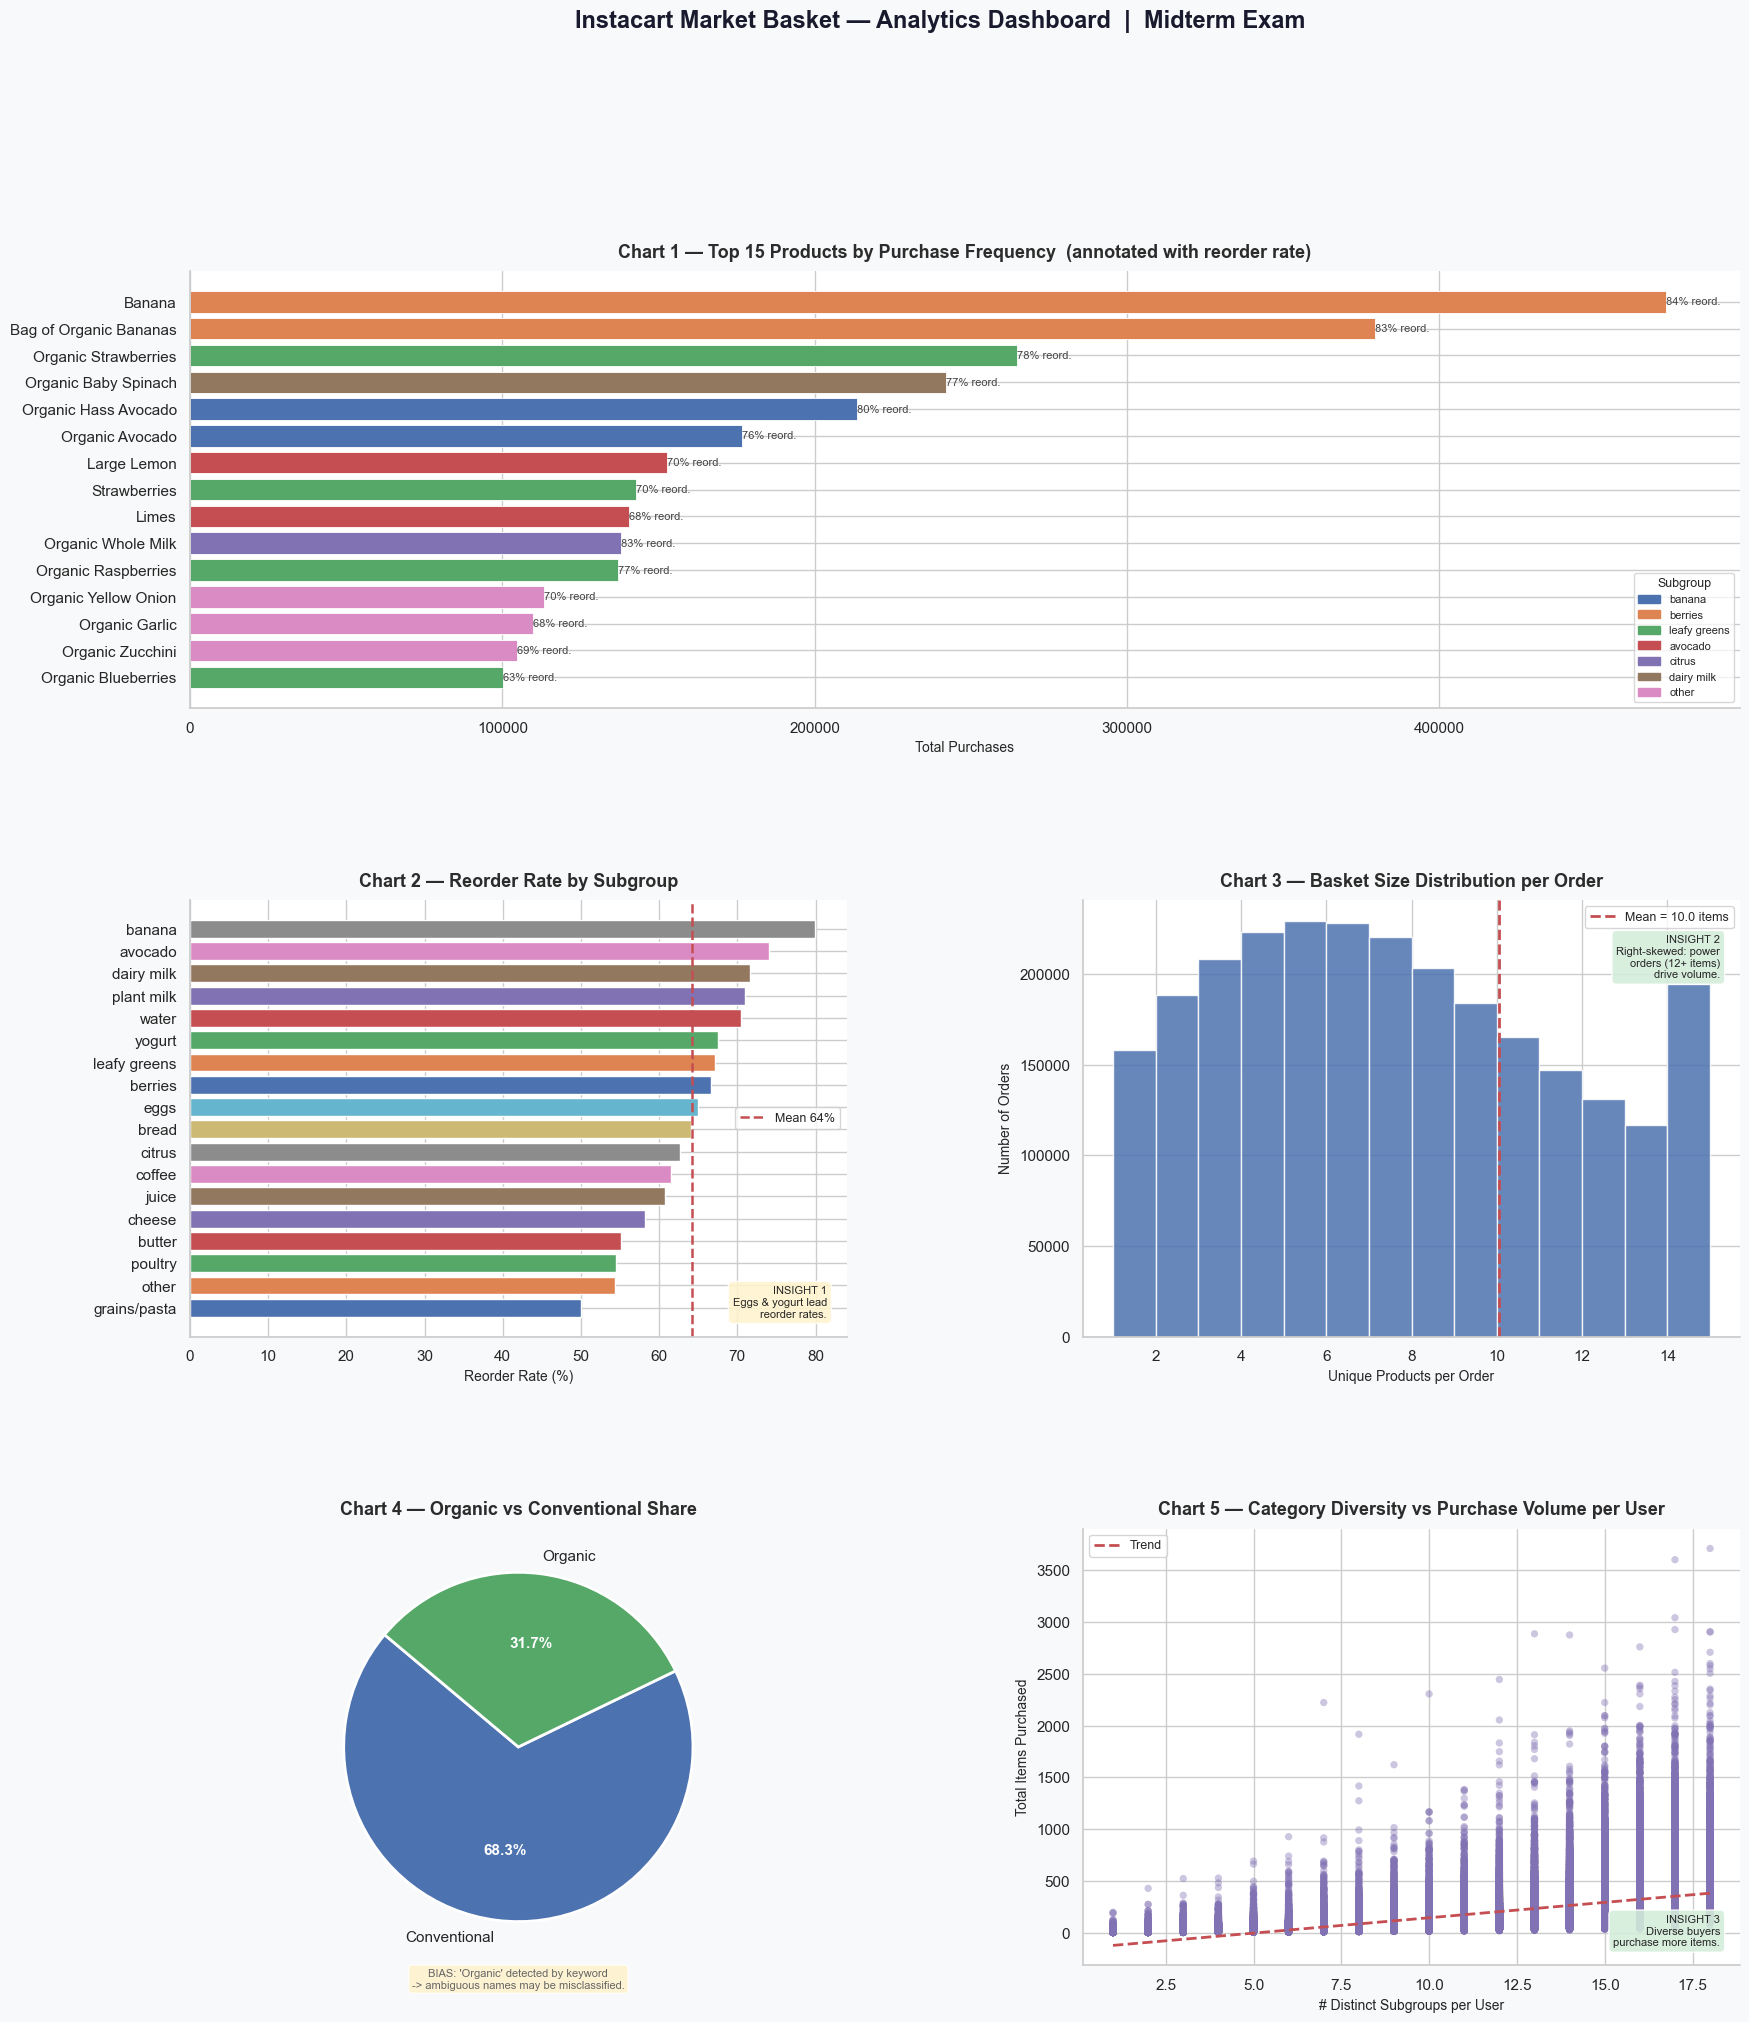

Chart saved -> instacart_analytics.png


In [25]:
# VISUALIZATIONS

sns.set_theme(style="whitegrid", palette="muted")
C = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B3",
     "#937860","#DA8BC3","#8C8C8C","#CCB974","#64B5CD"]

fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor("#F8F9FA")
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.44, wspace=0.36)
TKW = dict(fontsize=13, fontweight="bold", pad=10, color="#2C2C2C")
NB  = dict(boxstyle="round,pad=0.4", alpha=0.88)

# Chart 1: Top 15 Products 
ax1 = fig.add_subplot(gs[0, :])
ax1.set_facecolor("#FFFFFF")
colors1 = [C[i % len(C)] for i in top15["subgroup"].astype("category").cat.codes]
bars = ax1.barh(top15["product_name"][::-1], top15["purchases"][::-1],
                color=colors1[::-1], edgecolor="white", linewidth=0.6)
for bar, rr in zip(bars, top15["reorder_rate"][::-1]):
    ax1.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
             f"{rr:.0%} reord.", va="center", fontsize=8, color="#444")
legend_items = {sg: C[i % len(C)] for i, sg in enumerate(top15["subgroup"].unique())}
ax1.legend(handles=[mpatches.Patch(color=c, label=sg) for sg, c in legend_items.items()],
           title="Subgroup", fontsize=8, title_fontsize=9, loc="lower right", framealpha=0.75)
ax1.set_title("Chart 1 — Top 15 Products by Purchase Frequency  (annotated with reorder rate)", **TKW)
ax1.set_xlabel("Total Purchases", fontsize=10)
ax1.spines[["top","right"]].set_visible(False)

# Chart 2: Reorder Rate by Subgroup
ax2 = fig.add_subplot(gs[1, 0])
ax2.set_facecolor("#FFFFFF")
rr_sorted = reorder_sg.sort_values("reorder_rate")
ax2.barh(rr_sorted["subgroup"], rr_sorted["reorder_rate"] * 100,
         color=[C[i % len(C)] for i in range(len(rr_sorted))], edgecolor="white")
mean_rr = rr_sorted["reorder_rate"].mean()
ax2.axvline(mean_rr * 100, color="#C44E52", linestyle="--",
            linewidth=1.8, label=f"Mean {mean_rr:.0%}")
ax2.set_title("Chart 2 — Reorder Rate by Subgroup", **TKW)
ax2.set_xlabel("Reorder Rate (%)", fontsize=10)
ax2.legend(fontsize=9)
ax2.spines[["top","right"]].set_visible(False)
insight1 = "INSIGHT 1\nEggs & yogurt lead\nreorder rates."
ax2.text(0.97, 0.04, insight1, transform=ax2.transAxes,
         ha="right", va="bottom", fontsize=8, bbox=dict(**NB, facecolor="#FFF3CD"))

# Chart 3: Basket Size Distribution 
ax3 = fig.add_subplot(gs[1, 1])
ax3.set_facecolor("#FFFFFF")
mean_bs = baskets["basket_size"].mean()
ax3.hist(baskets["basket_size"], bins=range(1, 16), color=C[0], edgecolor="white", alpha=0.85)
ax3.axvline(mean_bs, color="#C44E52", linestyle="--", linewidth=2,
            label=f"Mean = {mean_bs:.1f} items")
ax3.set_title("Chart 3 — Basket Size Distribution per Order", **TKW)
ax3.set_xlabel("Unique Products per Order", fontsize=10)
ax3.set_ylabel("Number of Orders", fontsize=10)
ax3.legend(fontsize=9)
ax3.spines[["top","right"]].set_visible(False)
insight2 = "INSIGHT 2\nRight-skewed: power\norders (12+ items)\ndrive volume."
ax3.text(0.97, 0.92, insight2, transform=ax3.transAxes,
         ha="right", va="top", fontsize=8, bbox=dict(**NB, facecolor="#D4EDDA"))

# Chart 4: Organic vs Conventional 
ax4 = fig.add_subplot(gs[2, 0])
ax4.set_facecolor("#FFFFFF")
org_map = organic.set_index("is_organic")["cnt"]
sizes   = [org_map.get("Conventional", 0), org_map.get("Organic", 0)]
wedges, texts, autos = ax4.pie(
    sizes, labels=["Conventional", "Organic"],
    colors=[C[0], C[2]], autopct="%1.1f%%", startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    textprops=dict(fontsize=11)
)
for a in autos:
    a.set_fontsize(11); a.set_fontweight("bold"); a.set_color("white")
ax4.set_title("Chart 4 — Organic vs Conventional Share", **TKW)
bias_note = "BIAS: 'Organic' detected by keyword\n-> ambiguous names may be misclassified."
ax4.text(0, -1.38, bias_note, ha="center", fontsize=8, color="#666",
         bbox=dict(boxstyle="round,pad=0.3", facecolor="#FFF3CD", alpha=0.85))

# Chart 5: User Diversity vs Purchase Volume 
ax5 = fig.add_subplot(gs[2, 1])
ax5.set_facecolor("#FFFFFF")
ax5.scatter(diversity["n_subgroups"], diversity["total_items"],
            alpha=0.4, s=28, c=C[4], edgecolors="none")
m, b = np.polyfit(diversity["n_subgroups"], diversity["total_items"], 1)
xs = np.linspace(diversity["n_subgroups"].min(), diversity["n_subgroups"].max(), 100)
ax5.plot(xs, m * xs + b, color=C[3], linewidth=2, linestyle="--", label="Trend")
ax5.set_title("Chart 5 — Category Diversity vs Purchase Volume per User", **TKW)
ax5.set_xlabel("# Distinct Subgroups per User", fontsize=10)
ax5.set_ylabel("Total Items Purchased", fontsize=10)
ax5.legend(fontsize=9)
ax5.spines[["top","right"]].set_visible(False)
insight3 = "INSIGHT 3\nDiverse buyers\npurchase more items."
ax5.text(0.97, 0.04, insight3, transform=ax5.transAxes,
         ha="right", va="bottom", fontsize=8, bbox=dict(**NB, facecolor="#D4EDDA"))

fig.suptitle("Instacart Market Basket — Analytics Dashboard  |  Midterm Exam",
             fontsize=17, fontweight="bold", y=0.999, color="#1A1A2E")

plt.savefig("instacart_analytics.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()
print("Chart saved -> instacart_analytics.png")


In [26]:
# Key Insights + Bias Analysis

line = "=" * 64
print(line)
print("  KEY INSIGHTS")
print(line)
print("  INSIGHT 1 - Staple Reorder Dominance")
print("  Eggs, yogurt, dairy milk reorder well above average.")
print("  Users predictably replenish the same SKUs every cycle.")
print("  Action: Target these for subscription / auto-reorder.")
print()
print("  INSIGHT 2 - Power Orders Drive Disproportionate Volume")
print("  Basket size is right-skewed; ~10% orders have 12+ items.")
print("  Losing a power shopper has outsized revenue impact.")
print("  Action: Identify and retain high-basket-size users.")
print()
print("  INSIGHT 3 - Category Diversity Predicts Volume")
print("  Users who buy across more subgroups buy more items total.")
print("  Action: Cross-category promotions lift breadth and volume.")
print(line)
print("  HOW DQ ISSUES WOULD BIAS RESULTS (if not fixed)")
print(line)
print("  DQ-3 dupes     -> purchase counts & reorder rates inflated")
print("  DQ-2 variants  -> banana counted at 1/3 its true frequency")
print("  DQ-4 bad hour  -> phantom hour-99 spike in time charts")
print("  DQ-5 NULL dept -> 3 products missing from category reports")
print("  DQ-6 logic dup -> same product split into separate rows")
print(line)


  KEY INSIGHTS
  INSIGHT 1 - Staple Reorder Dominance
  Eggs, yogurt, dairy milk reorder well above average.
  Users predictably replenish the same SKUs every cycle.
  Action: Target these for subscription / auto-reorder.

  INSIGHT 2 - Power Orders Drive Disproportionate Volume
  Basket size is right-skewed; ~10% orders have 12+ items.
  Losing a power shopper has outsized revenue impact.
  Action: Identify and retain high-basket-size users.

  INSIGHT 3 - Category Diversity Predicts Volume
  Users who buy across more subgroups buy more items total.
  Action: Cross-category promotions lift breadth and volume.
  HOW DQ ISSUES WOULD BIAS RESULTS (if not fixed)
  DQ-3 dupes     -> purchase counts & reorder rates inflated
  DQ-2 variants  -> banana counted at 1/3 its true frequency
  DQ-4 bad hour  -> phantom hour-99 spike in time charts
  DQ-5 NULL dept -> 3 products missing from category reports
  DQ-6 logic dup -> same product split into separate rows


---
## 🚀 Optional — What Breaks at 100× Scale?

| Component | Problem at 100× | Fix |
|---|---|---|
| `F.broadcast()` | Tables grow to GB → driver OOM | Switch to `SortMergeJoin` with pre-bucketed tables |
| `rank()` window over `user_id` | Power-user → skewed hot partition → OOM | Salt the partition key or use approximate top-k |
| `.cache()` | GB-range spills to disk, negating the speedup | Write to Parquet on HDFS/S3 instead |
| `shuffle.partitions = 8` | Each partition becomes GBs → memory pressure | Scale to 200–2000 |
| Python UDF (if kept) | ~10× slower for 100× more rows | Already replaced with native expressions |
| CSV source | No partition/column pruning, no statistics | Convert to Parquet with `partitionBy("user_id")` |
